In [10]:
import sys

sys.path.append("../src/")

import crowding
import matplotlib.pyplot as plt
import rotations
import torch
from fft_tools import fft2
from imagegenerator import ImageGenerator
from microscope import Aberration, Detector
from pdb2mrc import PDB2MRC
from plotting_tools import *
from scattering import Scattering, complex_potential
from tqdm import tqdm
from matplotlib.collections import PatchCollection

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
# fetch pdb file
# note: warnings are from biopython, can be ignored.
pdb_code = "2HBS"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/", assembly=1)

/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4380.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4423.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4466.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4509.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4552.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem

Assemblies available: 1, 2
2HBS: Fetching Biological Assembly 1
File already exists: ../pdb-data/2HBS-assembly1.cif


4827it [00:00, 159720.93it/s]


In [115]:
pm.max_diameter

70.2264987557542

In [192]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 2  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00,  5.08it/s]


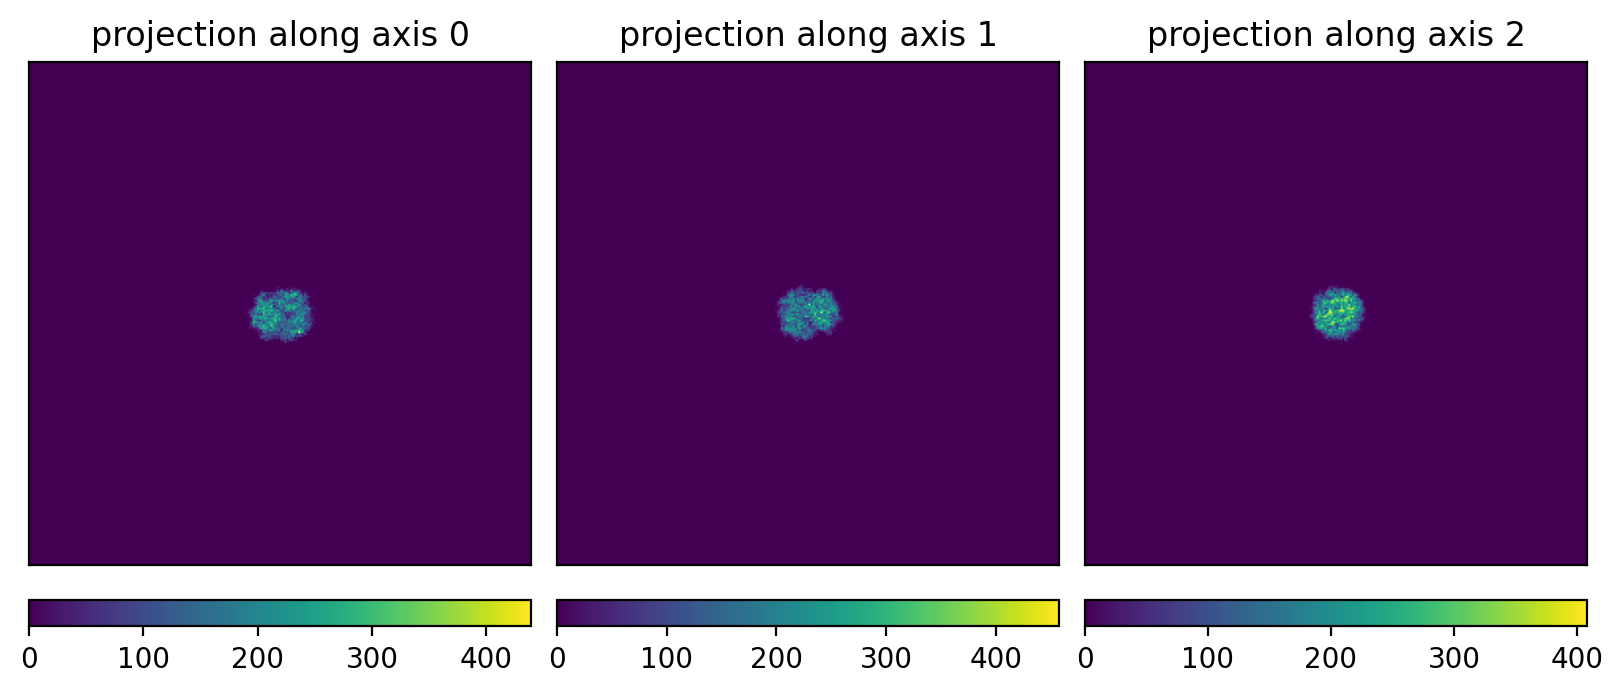

In [193]:
plot3d(V)

In [204]:
crowd, translations = crowding.crowd_with_duplicates(V, pm.max_diameter*0.9, pixel_size=dx, return_coordinates=True)

In [205]:
x = torch.concat((translations[:,0], torch.tensor([0])))
y = torch.concat((translations[:,1], torch.tensor([0])))

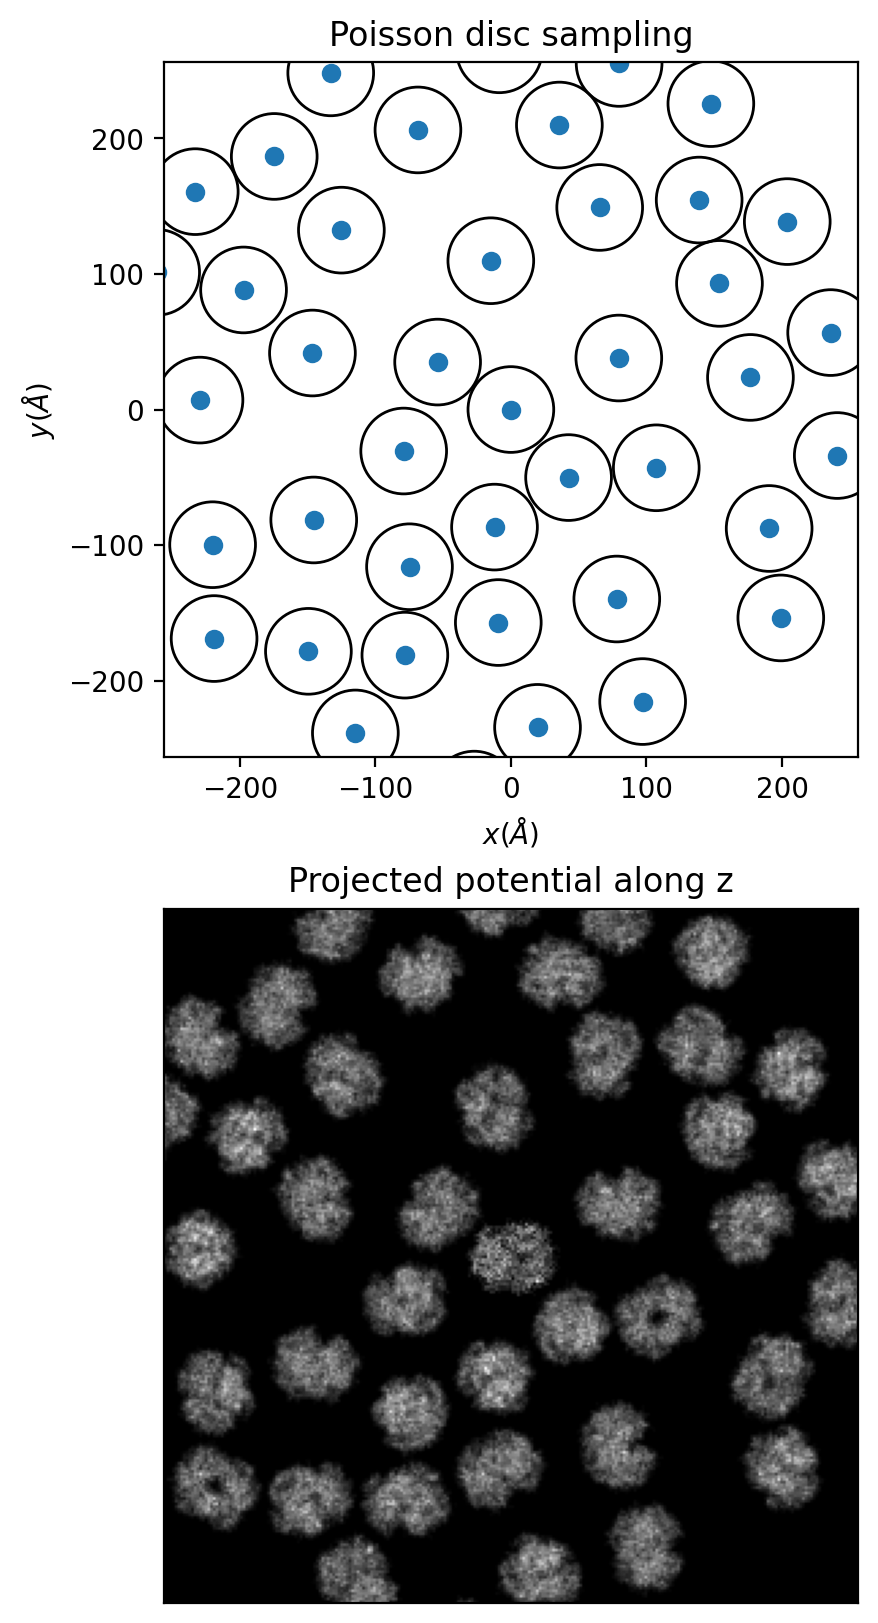

In [206]:
fig, axes = plt.subplots(2, 1, dpi=200, figsize=(14,8), constrained_layout=True)
ax = axes[0]
_ = ax.scatter(-x, y)
circles = [plt.Circle((-xi, yi), radius=pm.max_diameter*0.9 / 2, fill=False) for xi, yi in zip(x,y)]
collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)
_ = ax.set(
    aspect="equal", xlabel=r"$x (\AA)$", ylabel=r"$y (\AA)$", xlim=[-dx*n/2, dx*n/2], ylim=[-dx*n/2, dx*n/2]
)
ax.set_title('Poisson disc sampling')

ax = axes[1]
ax.imshow((V + crowd).sum(0), cmap='grey')
ax.set(xticks=[], yticks=[])
ax.set_title('Projected potential along z')
plt.show()